In [1]:
import numpy as np
from rigaku_handler import RigakuDataset
import matplotlib.pyplot as plt
import skimage.io as skio
from tqdm import trange

In [18]:
!ls -lh A029_AgNO3_2ml_TEOS_20ml_025C_att00_Rq0_00001.bin


-rw-r--r--@ 1 mqichu  staff   144M Apr 26 17:07 A029_AgNO3_2ml_TEOS_20ml_025C_att00_Rq0_00001.bin


In [13]:
151397016 // 8

18924627

In [15]:
100e3 * 512 * 1024 * 2 // 1024 ** 3

97.0

In [17]:
151397016 / (100e3 * 512 * 1024 * 2)

0.001443834457397461

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:42<00:00, 234.51it/s]


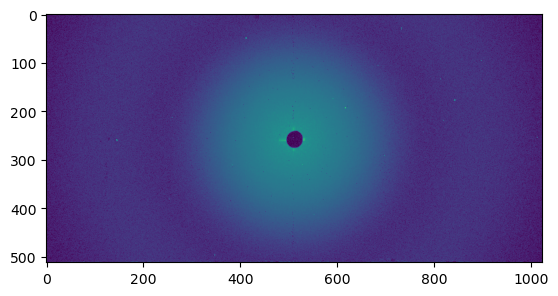

In [2]:

shape = (512, 1024)
# prepare blemish file
# mask = skio.imread('rigaku3m_blemish.tiff')

# prepare dataset
batch_size = 10   # number of frames per batch, since there are so many
                    # frames in each dataset
fname = "A029_AgNO3_2ml_TEOS_20ml_025C_att00_Rq0_00001.bin"
dset = RigakuDataset(fname, batch_size=batch_size)
frame_sum = 0
# read data
for idx in trange(dset.batch_num):
    batch = dset[idx].reshape(batch_size, *shape)
    # each batch has 1000 2D 2D frames
    frame_sum += batch.sum(axis=0)
    # if idx == 10:
    #     break

# frame_sum = frame_sum * mask 
plt.imshow(np.log10(frame_sum + 1))
plt.show()
    


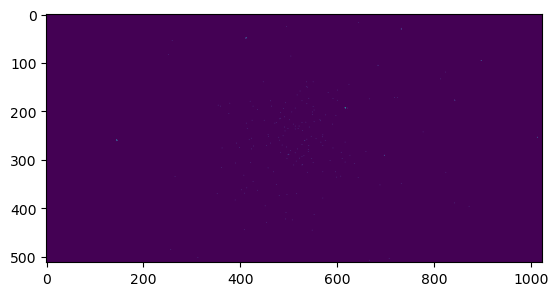

In [6]:
# prepare dataset
batch_size = 1   # number of frames per batch, since there are so many
                    # frames in each dataset
fname = "A029_AgNO3_2ml_TEOS_20ml_025C_att00_Rq0_00001.bin"
dset = RigakuDataset(fname, batch_size=batch_size)
x = dset[0].reshape(1, *shape)[0]
plt.imshow(x)

In [8]:
np.min(x), np.max(x), np.sum(x == 0) / x.size

(0, 3, 0.9996356964111328)